# Separation between FK5 and ICRS

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube, Projection
from astropy.modeling import models, fitting
from astropy.convolution import convolve_models
from astropy import units as u
from astropy.io import fits
import radio_beam
from radio_beam import Beam
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord

/Users/galagabits/miniconda3/envs/masers/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Code for fitting 2D Gaussians and storing measurements in a table, including SkyCoords.

In [2]:
#Accessing Cube Data
def fit_2dgaussian(directory, maser_table, freq, amplitude, x, y, x_stddev, y_stddev, theta=np.pi/3, size=13, channel=0, cube=True, format='fits', table=True, source_name='None'):

    """
    Fit a 2D Gaussian to a cutout of a spectral cube or image.

    """

    if cube:
        
        cube = SpectralCube.read(directory, format=format)

        if channel is None:
            pass
        else:
            cube = cube[channel,:,:]

        cube_cutout = cube[y - size:y + size, x - size:x + size]
        yy, xx = cube_cutout.spatial_coordinate_map

        cord = cube.world[y,x]

        x_guess, y_guess = cord[1], cord[0]

    else:
        
        hdul = fits.open(directory)

        hdu = hdul[0]

        data_cube = hdul[0].data

        if data_cube.ndim == 4:
            data = data_cube[0, 0, :, :] * u.Jy/u.beam

        else:
            data = hdu.data * u.Jy/u.beam

        header = hdu.header

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            ww = WCS(header)

        data_cutout = data[y - size:y + size, x - size:x + size]
        ypixel_grid, xpixel_grid = np.mgrid[y - size:y + size, x - size:x + size]
        
        # xx, yy = ww.pixel_to_world_values(xpixel_grid, ypixel_grid)

        # xx = (xx * u.deg)
        # yy = (yy * u.deg)

        # x_guess, y_guess = xx[size, size], ypixel_grid[size, size]


    p_init_gauss2D = models.Gaussian2D(x_mean=x, y_mean=y, amplitude=amplitude * (u.Jy/u.beam),
                                    x_stddev=(x_stddev), y_stddev=(y_stddev), theta=(theta)*u.rad)

    fit_p = fitting.LevMarLSQFitter()
    data_cutout[np.isnan(data_cutout)] = 0.

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p_gauss2D = fit_p(p_init_gauss2D, xpixel_grid, ypixel_grid, data_cutout)

    p_init_gauss2D.theta.fixed = True

    cov = np.diag(fit_p.fit_info['param_cov'])
    errors = np.sqrt(cov)

    amplitude_error=np.format_float_scientific(errors[0],precision=9)
    x_mean_error=np.format_float_scientific(errors[1],precision=9)
    y_mean_error=np.format_float_scientific(errors[2],precision=9)
    x_stddev_error=np.format_float_scientific(errors[3],precision=9)
    y_stddev_error=np.format_float_scientific(errors[4],precision=9)
    theta_error=np.format_float_scientific(errors[5],precision=9)

    amplitude = np.format_float_scientific(p_gauss2D.amplitude[0],precision=9)
    x_mean = np.format_float_scientific(p_gauss2D.x_mean[0],precision=9)
    y_mean = np.format_float_scientific(p_gauss2D.y_mean[0],precision=9)
    x_stddev = np.format_float_scientific(p_gauss2D.x_stddev[0],precision=9)
    y_stddev = np.format_float_scientific(p_gauss2D.y_stddev[0],precision=9)
    theta = np.format_float_scientific(p_gauss2D.theta[0],precision=9)

                
    plt.figure(figsize=(20, 6))
    plt.suptitle(f"Source-{source_name} freq-{freq}", fontsize=18)

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(data_cutout.value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("Model")
    plt.imshow(p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Residual")
    plt.imshow(data_cutout.value - p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar(label='S (Jy)')

    plt.show()

    print("Parameter" + ' ' + 'Error' +"\n")
    print("Amplitude" +"\n")
    print(amplitude + ' ' + amplitude_error +"\n")

    print("x_mean"  +"\n")
    print(x_mean + ' ' + x_mean_error +"\n")

    print("y_mean" +"\n")
    print(y_mean + ' ' + y_mean_error +"\n")

    print("x_stddev" +"\n")
    print(x_stddev + ' ' + x_stddev_error +"\n")

    print("y_stddev" +"\n")
    print(y_stddev + ' ' + y_stddev_error +"\n")

    print("theta" +"\n")
    print(theta + ' ' + theta_error +"\n")

    # print('\n\nSkyCoord Conversion \n----------------- \n')
    # print("Parameter" + ' ' + 'Error' +"\n")

    skycoord = pixel_to_skycoord(float(x_mean), float(y_mean), ww)

    # error propagation? # Not sure if this is correct
    skycoord_error = pixel_to_skycoord(float(x_mean_error), float(y_mean_error), ww)

    print(skycoord_error)

    if table:
        new_row = pd.DataFrame({'source': [source_name] , 
            'freq': [freq], 'x_pix': [x], 'y_pix': [y], 'amplitude': [amplitude], 
            'amplitude_error': [amplitude_error], 'x_mean': [x_mean], 'x_mean_error': [x_mean_error], 
            'y_mean': [y_mean], 'y_mean_error': [y_mean_error], 
            'x_mean_sky': [skycoord.ra.deg], 'x_mean_sky_error': [skycoord_error.ra.deg],
            'y_mean_sky': [skycoord.dec.deg], 'y_mean_sky_error': [skycoord_error.dec.deg],
            'SkyCoord' : [skycoord],
            'frame': [skycoord.frame.name], 
            'header': [ww]})
        maser_table = pd.concat([maser_table, new_row], ignore_index=True)

        return maser_table

### Positions for Sources in FK5 File

In [3]:
ca3_positions = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 'SkyCoord', 'frame', 'header'])

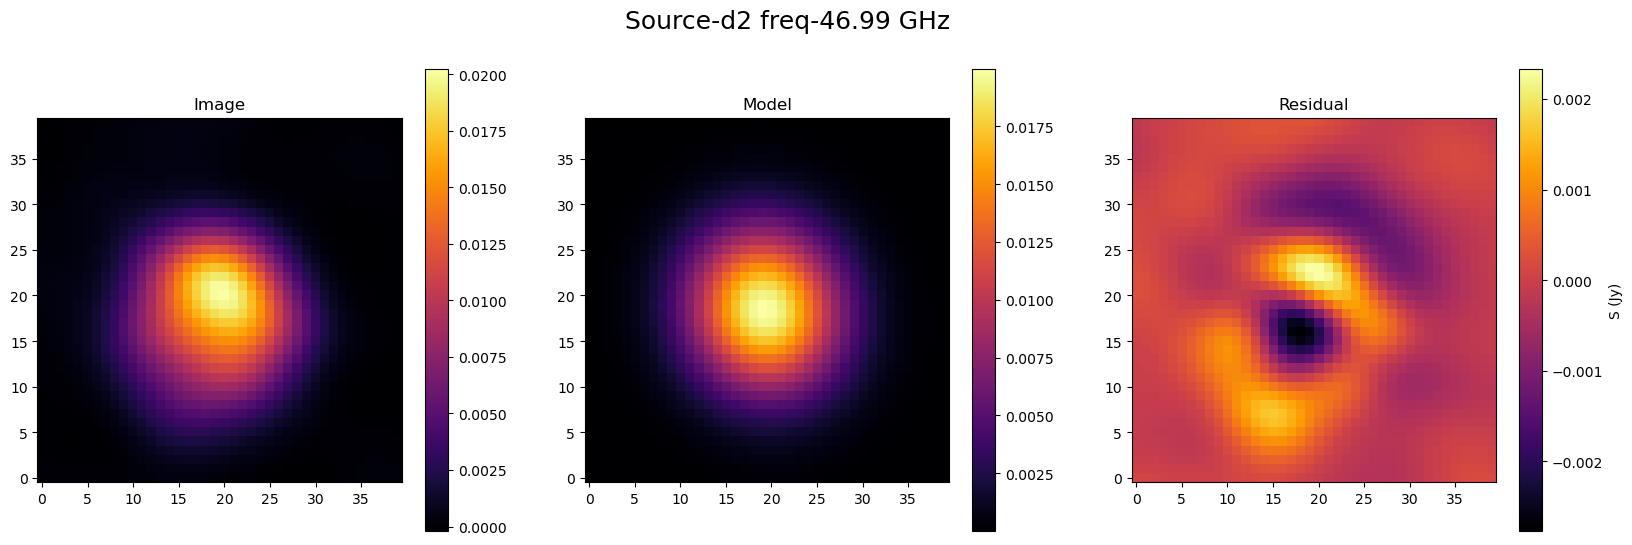

Parameter Error

Amplitude

2.003131054e-02 5.798740937e-04

x_mean

8.157218783e+03 1.666791883e-01

y_mean

7.379360873e+03 1.797205898e-01

x_stddev

5.705071729e+00 1.65151606e-01

y_stddev

6.257812356e+00 1.812695815e-01

theta

-5.97360242e+00 2.210590474e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.92760951, 14.50775556)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_23815/4201039271.py:140: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


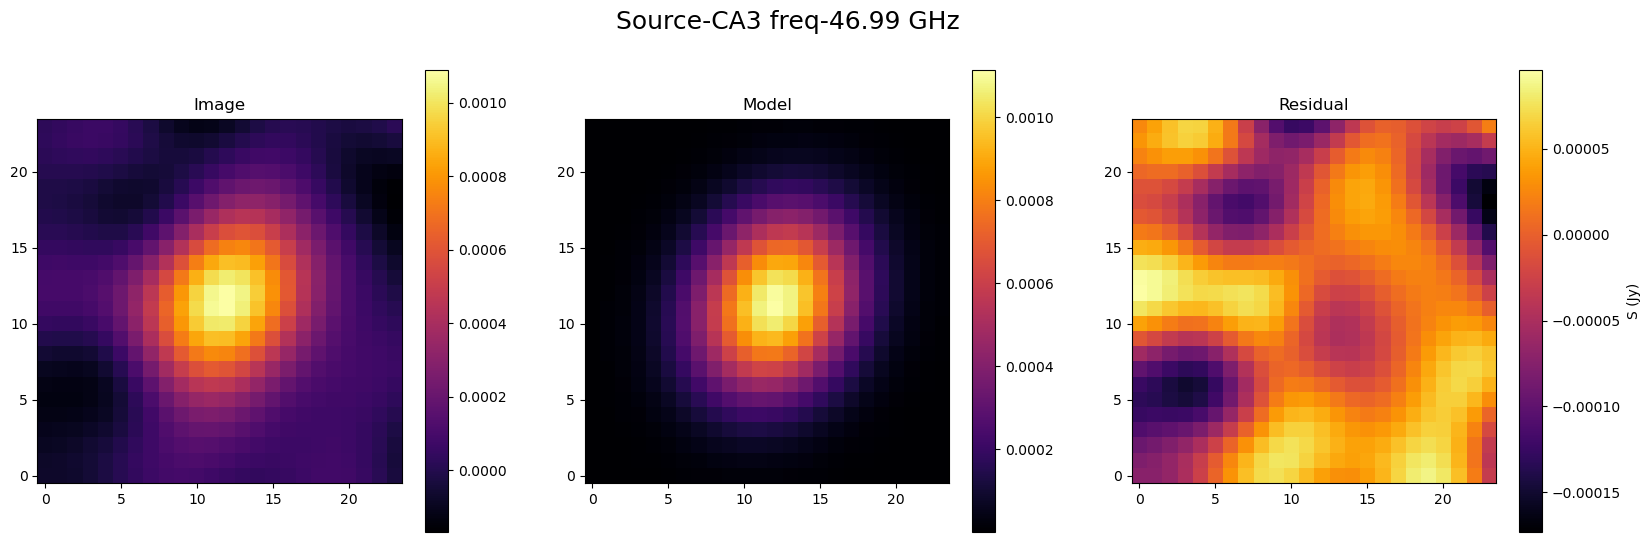

Parameter Error

Amplitude

1.118561057e-03 6.902485057e-05

x_mean

7.345059411e+03 2.223309533e-01

y_mean

7.543367160e+03 2.494930593e-01

x_stddev

4.194490305e+00 2.591225626e-01

y_stddev

3.429205715e+00 2.115685415e-01

theta

1.051719974e+01 2.152951863e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.92760943, 14.50775565)>


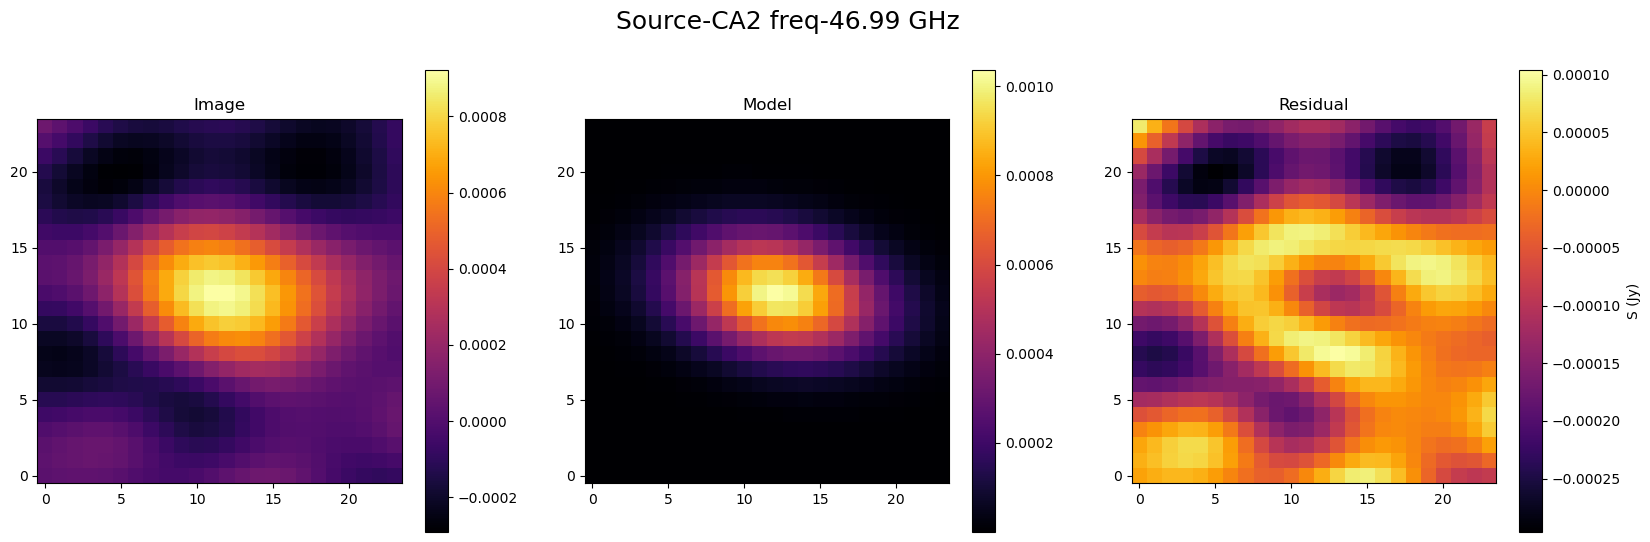

Parameter Error

Amplitude

1.037389063e-03 1.603143102e-04

x_mean

7.345172656e+03 6.796907057e-01

y_mean

7.564952762e+03 4.000221871e-01

x_stddev

2.521472837e+00 3.889967502e-01

y_stddev

4.44193214e+00 6.910227686e-01

theta

1.082957243e+01 1.829446575e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.92760878, 14.50775586)>


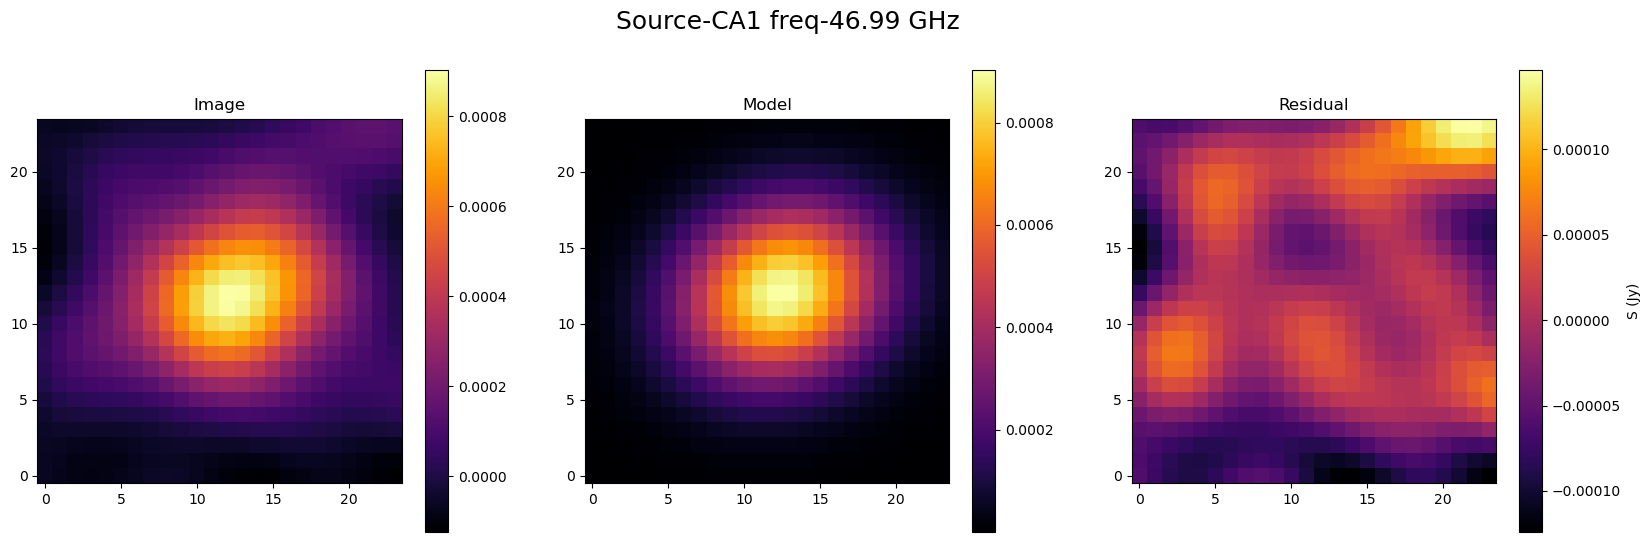

Parameter Error

Amplitude

9.069292056e-04 5.200514466e-05

x_mean

7.289449384e+03 2.617564795e-01

y_mean

7.569039755e+03 2.280370004e-01

x_stddev

4.664307755e+00 2.700093351e-01

y_stddev

3.875129671e+00 2.219972492e-01

theta

-9.054149092e+00 2.178764914e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.92760938, 14.50775562)>


In [ ]:
directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/originals_WCS_CRVAL/W51_North_QbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal4_final.image.tt0.pbcor_FK5.fits'

# d2
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=8158, y=7381, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=20, freq='46.99 GHz', source_name='d2')

# CA3
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=7345, y=7544, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA3')

# CA2
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=7345, y=7565, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA2')

# CA1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=7289, y=7569, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA1')

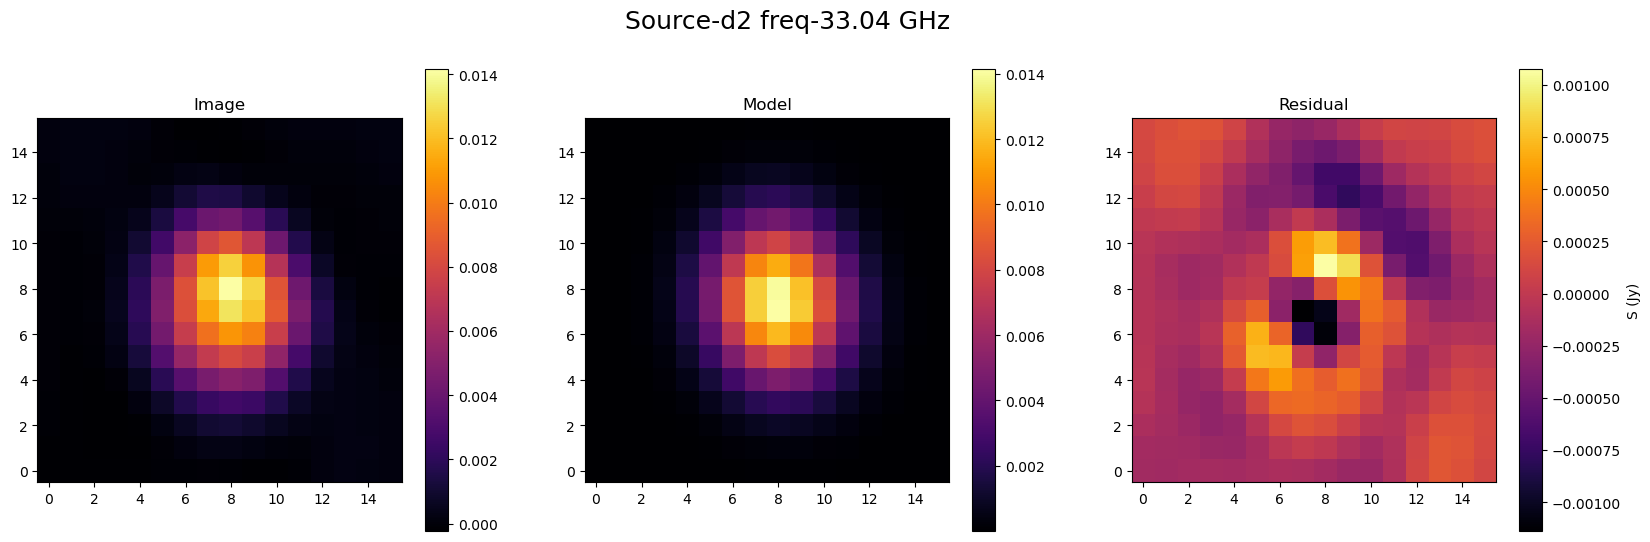

Parameter Error

Amplitude

1.439632876e-02 5.618912281e-04

x_mean

5.218962184e+03 7.746872079e-02

y_mean

4.959437972e+03 9.112219274e-02

x_stddev

2.34119335e+00 9.138777530e-02

y_stddev

1.977232816e+00 7.716998241e-02

theta

1.710256766e+00 1.625633834e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.93836816, 14.49733828)>


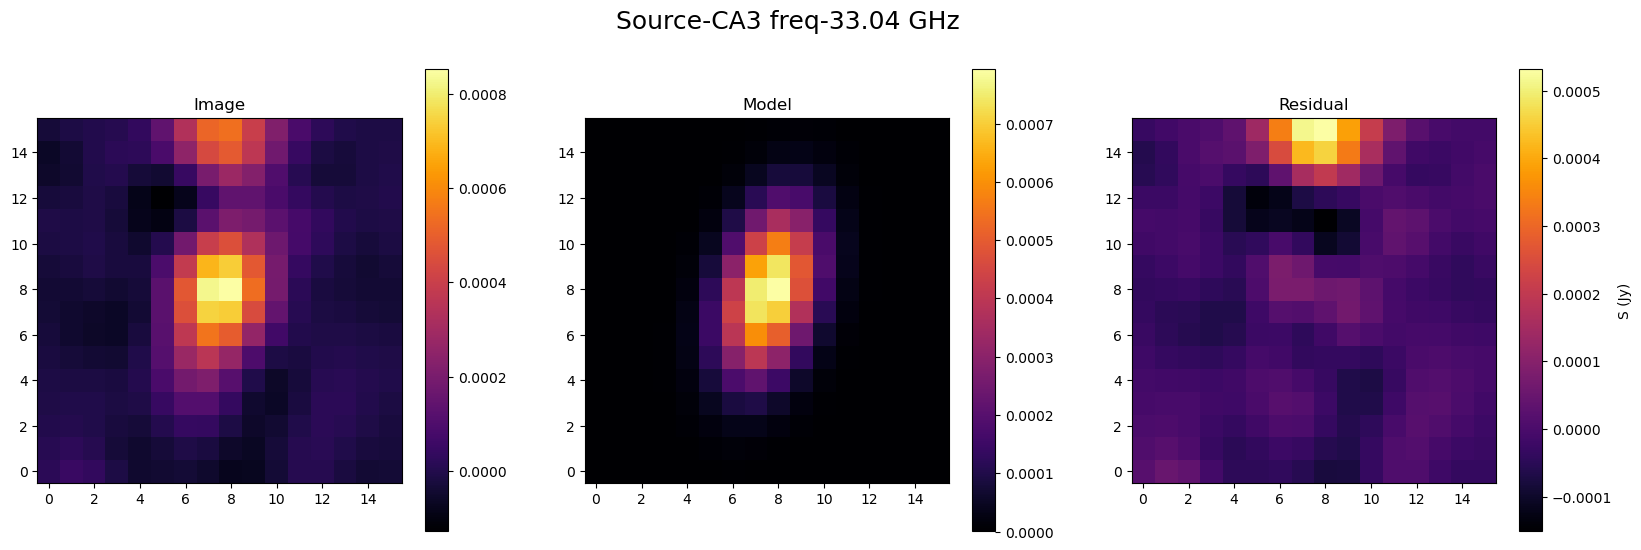

Parameter Error

Amplitude

8.305511630e-04 1.972342333e-04

x_mean

4.948582191e+03 3.321593183e-01

y_mean

5.014913826e+03 5.694345869e-01

x_stddev

2.455766208e+00 5.834011245e-01

y_stddev

1.294306978e+00 3.073482895e-01

theta

1.313808879e+00 2.450564938e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.93836707, 14.49734028)>


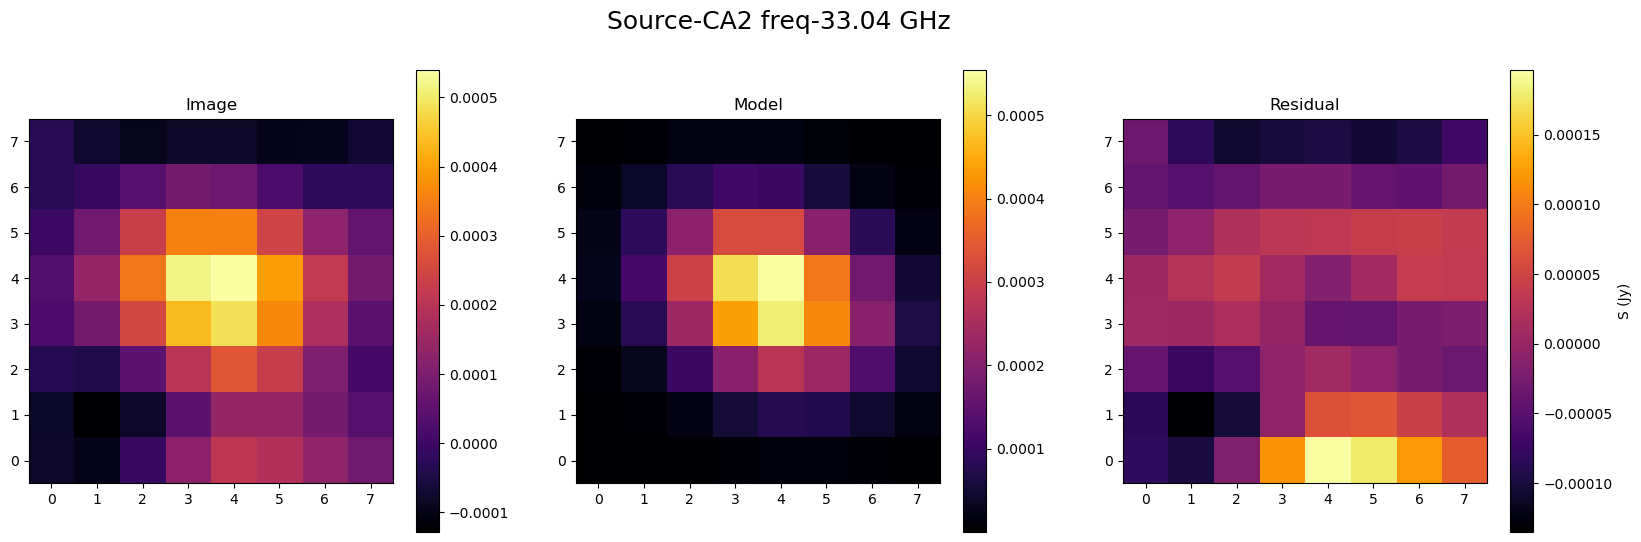

Parameter Error

Amplitude

5.897058205e-04 2.104617761e-04

x_mean

4.948779772e+03 5.484791165e-01

y_mean

5.021621338e+03 4.667829145e-01

x_stddev

1.24217617e+00 4.42722859e-01

y_stddev

1.594001700e+00 5.7324124e-01

theta

1.138135410e+00 1.003067345e+00

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.93836614, 14.49733985)>


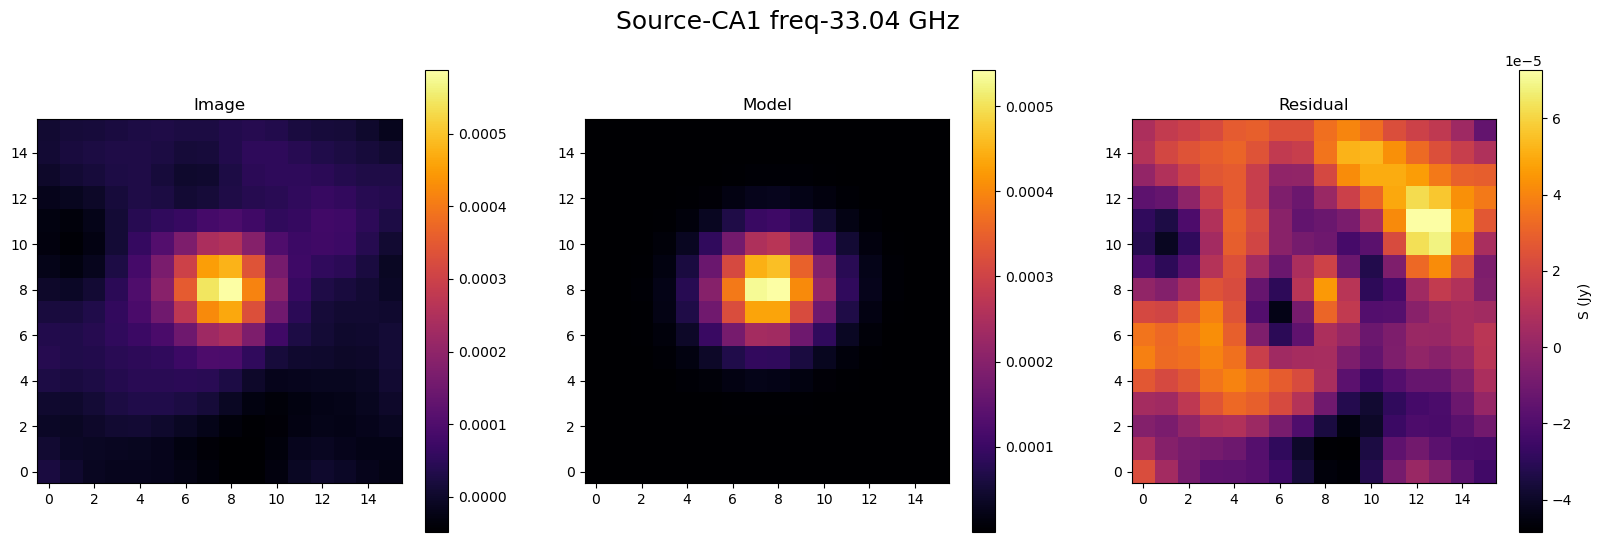

Parameter Error

Amplitude

5.594808435e-04 6.157723311e-05

x_mean

4.929562141e+03 1.971685316e-01

y_mean

5.02306136e+03 1.777839804e-01

x_stddev

1.602415786e+00 1.763683994e-01

y_stddev

1.802876738e+00 1.984357952e-01

theta

1.819476710e+00 6.586319578e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.93836765, 14.49733865)>


In [5]:
directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/originals_WCS_CRVAL/W51_North_KabandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal2.image.tt0.pbcor.fits'

ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=0.03, x=5219, y=4960, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=8, freq='33.04 GHz', source_name='d2')

ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=0.03, x=4949, y=5015, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=8, freq='33.04 GHz', source_name='CA3')

ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=0.03, x=4949, y=5022, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=4, freq='33.04 GHz', source_name='CA2')

ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=0.03, x=4930, y=5023, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=8, freq='33.04 GHz', source_name='CA1')

In [6]:
ca3_positions_ICRS = pd.DataFrame(columns=['source', 'freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error'])

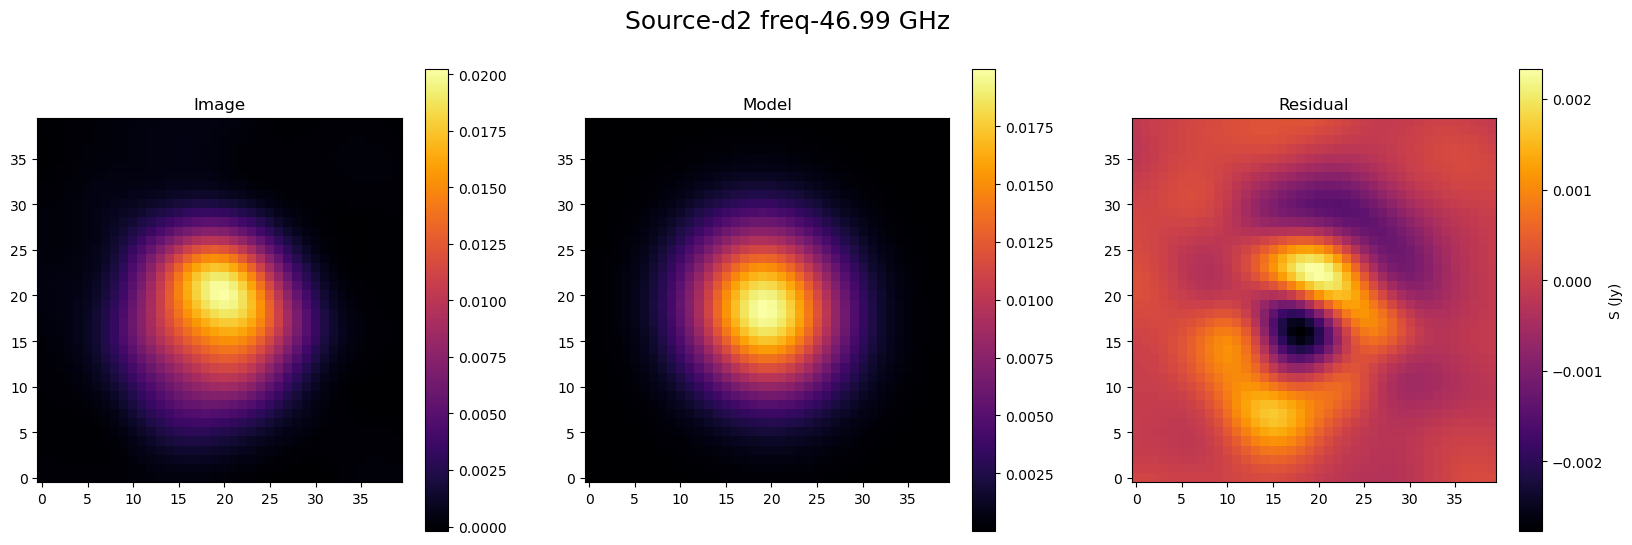

Parameter Error

Amplitude

2.003130207e-02 5.798905635e-04

x_mean

8.157218806e+03 1.666761846e-01

y_mean

7.379360915e+03 1.797138331e-01

x_stddev

5.705072904e+00 1.651467934e-01

y_stddev

6.257816383e+00 1.812643865e-01

theta

3.451182662e+00 2.210565235e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760325, 14.50774949)>


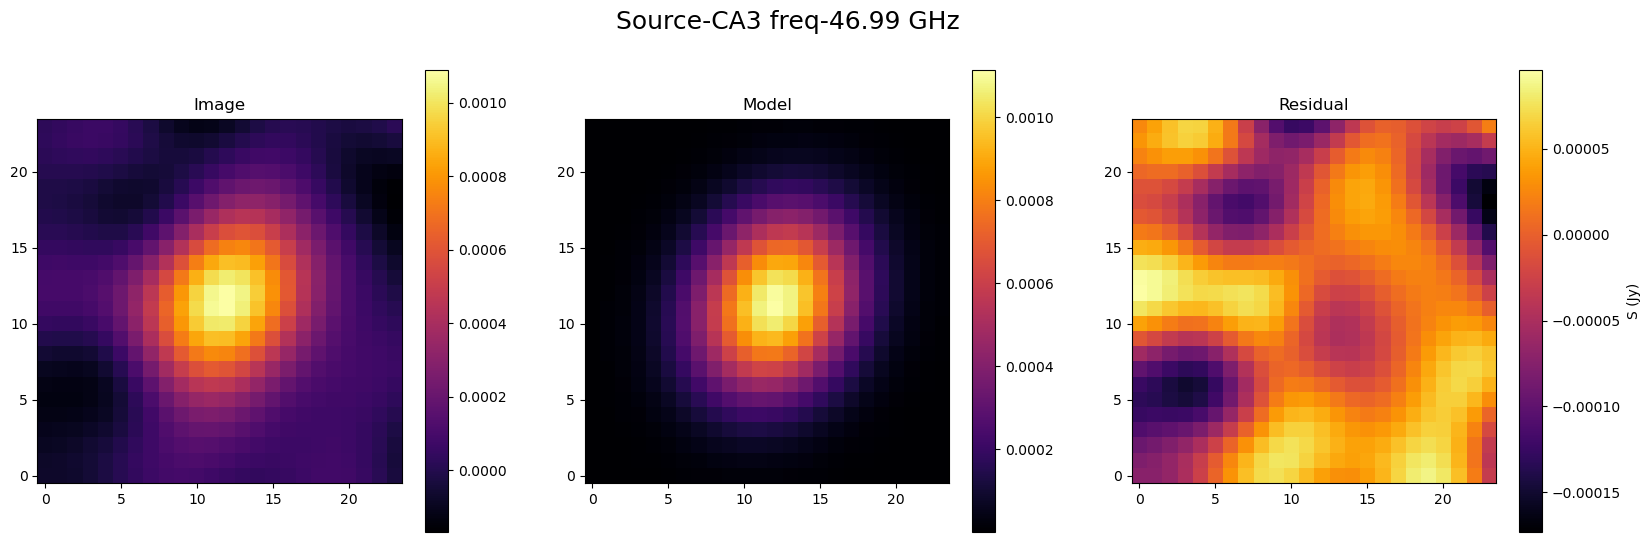

Parameter Error

Amplitude

1.118561057e-03 6.902485057e-05

x_mean

7.345059411e+03 2.223309533e-01

y_mean

7.543367160e+03 2.494930593e-01

x_stddev

4.194490305e+00 2.591225626e-01

y_stddev

3.429205715e+00 2.115685415e-01

theta

1.051719974e+01 2.152951863e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760317, 14.50774959)>


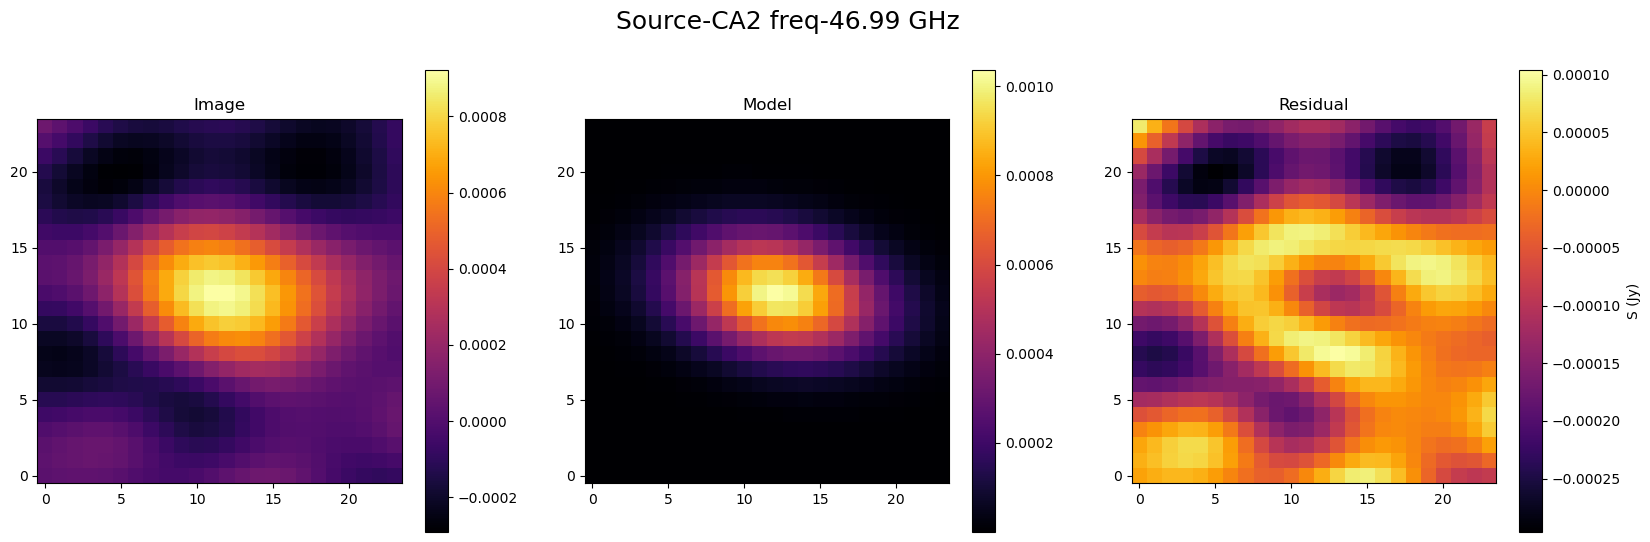

Parameter Error

Amplitude

1.037389063e-03 1.603143102e-04

x_mean

7.345172656e+03 6.796907057e-01

y_mean

7.564952762e+03 4.000221871e-01

x_stddev

2.521472837e+00 3.889967502e-01

y_stddev

4.44193214e+00 6.910227686e-01

theta

1.082957243e+01 1.829446575e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760252, 14.5077498)>


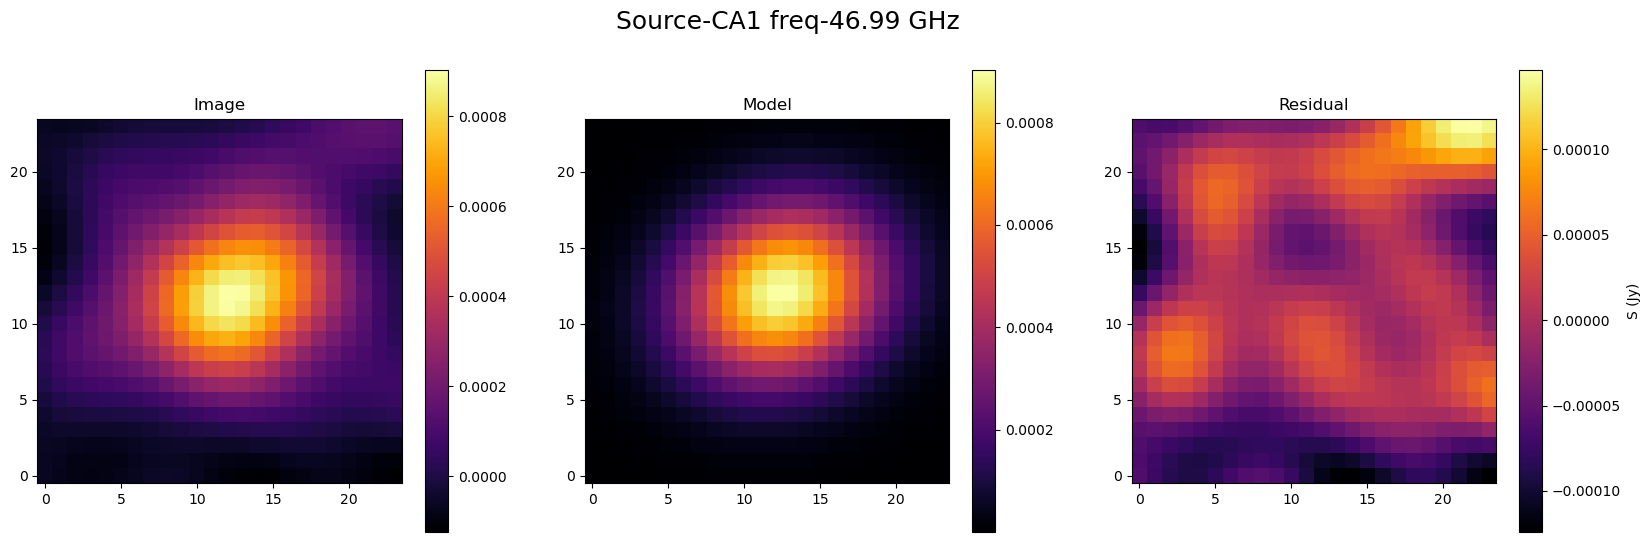

Parameter Error

Amplitude

9.069292056e-04 5.200514466e-05

x_mean

7.289449384e+03 2.617564795e-01

y_mean

7.569039755e+03 2.280370004e-01

x_stddev

4.664307755e+00 2.700093351e-01

y_stddev

3.875129671e+00 2.219972492e-01

theta

-9.054149092e+00 2.178764914e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760312, 14.50774956)>


In [7]:
# Q Band Sources

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/originals_WCS_CRVAL/ICRS/W51_North_QbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal4_final.image.tt0.pbcor_ICRS_CRVAL_change.fits'

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=1, x=8158, y=7381, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=20, freq='46.99 GHz', source_name='d2')

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=1, x=7345, y=7544, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA3')

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=1, x=7345, y=7565, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA2')

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=1, x=7289, y=7569, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA1')

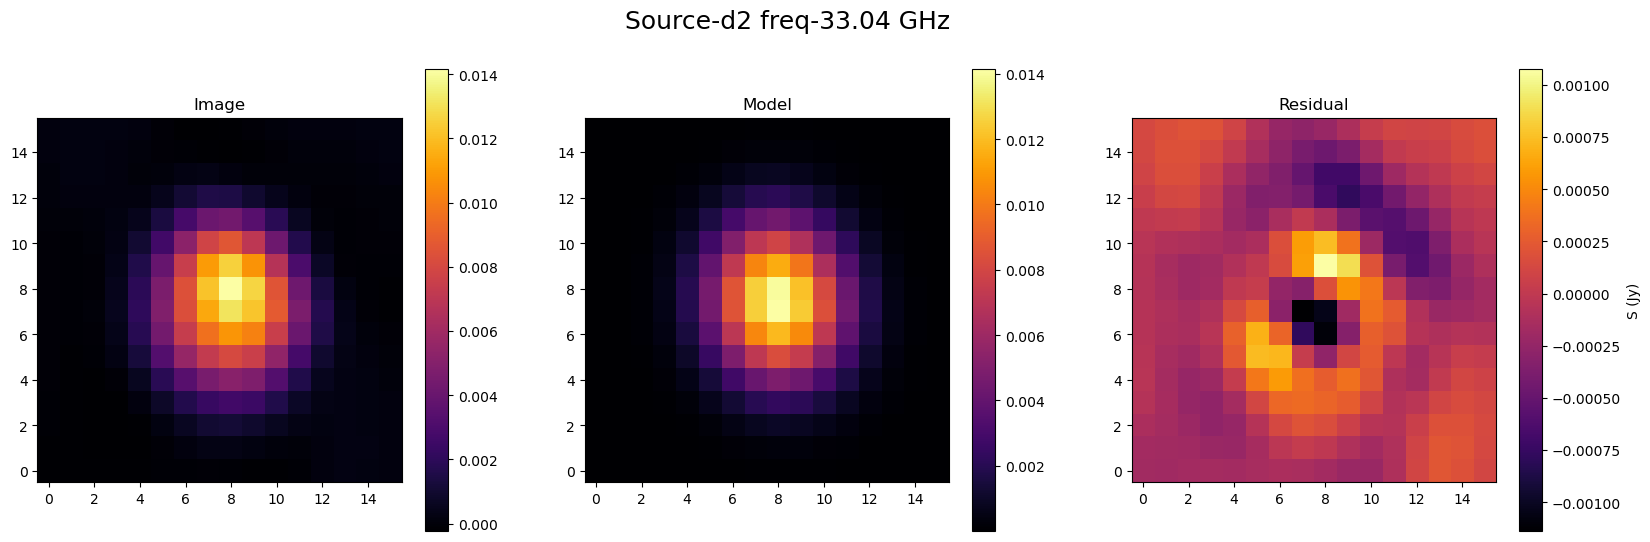

Parameter Error

Amplitude

1.439632876e-02 5.618912281e-04

x_mean

5.218962184e+03 7.746872079e-02

y_mean

4.959437972e+03 9.112219274e-02

x_stddev

2.34119335e+00 9.138777530e-02

y_stddev

1.977232816e+00 7.716998241e-02

theta

1.710256766e+00 1.625633834e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.9383619, 14.49733222)>


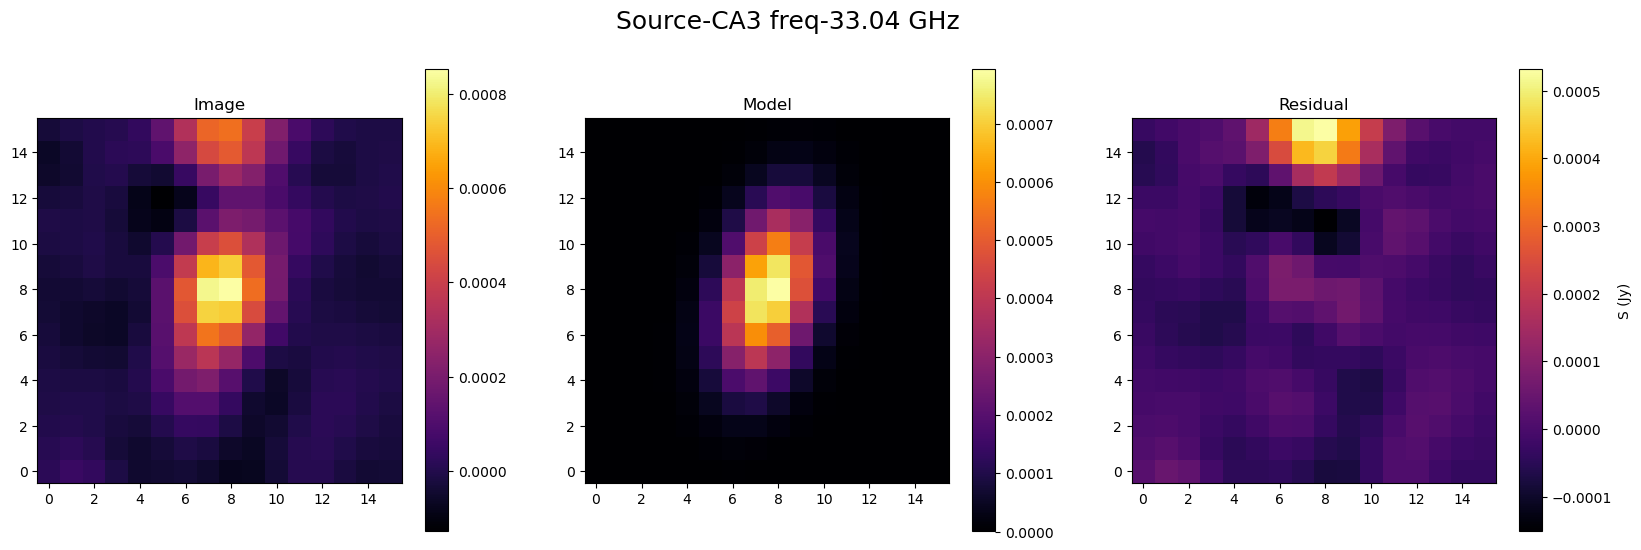

Parameter Error

Amplitude

8.305511630e-04 1.972342333e-04

x_mean

4.948582191e+03 3.321593183e-01

y_mean

5.014913826e+03 5.694345869e-01

x_stddev

2.455766208e+00 5.834011245e-01

y_stddev

1.294306978e+00 3.073482895e-01

theta

1.313808879e+00 2.450564938e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836081, 14.49733421)>


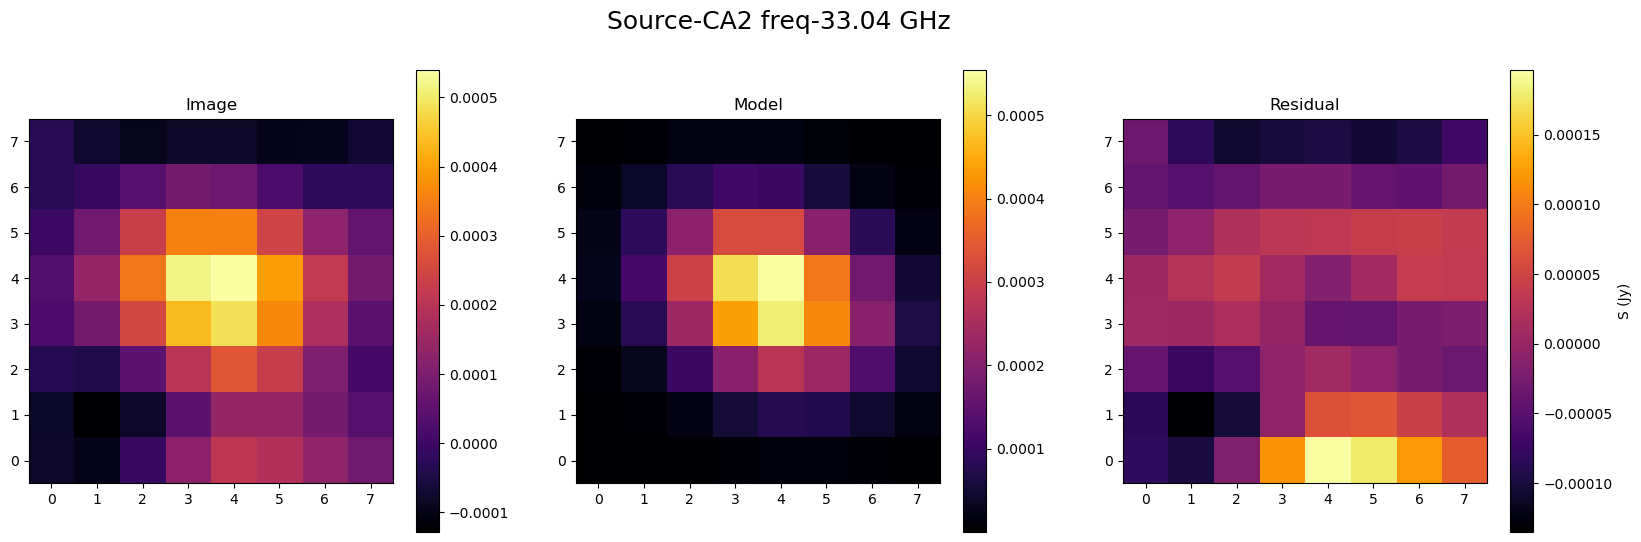

Parameter Error

Amplitude

5.897058205e-04 2.104617761e-04

x_mean

4.948779772e+03 5.484791165e-01

y_mean

5.021621338e+03 4.667829145e-01

x_stddev

1.24217617e+00 4.42722859e-01

y_stddev

1.594001700e+00 5.7324124e-01

theta

1.138135410e+00 1.003067345e+00

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93835988, 14.49733378)>


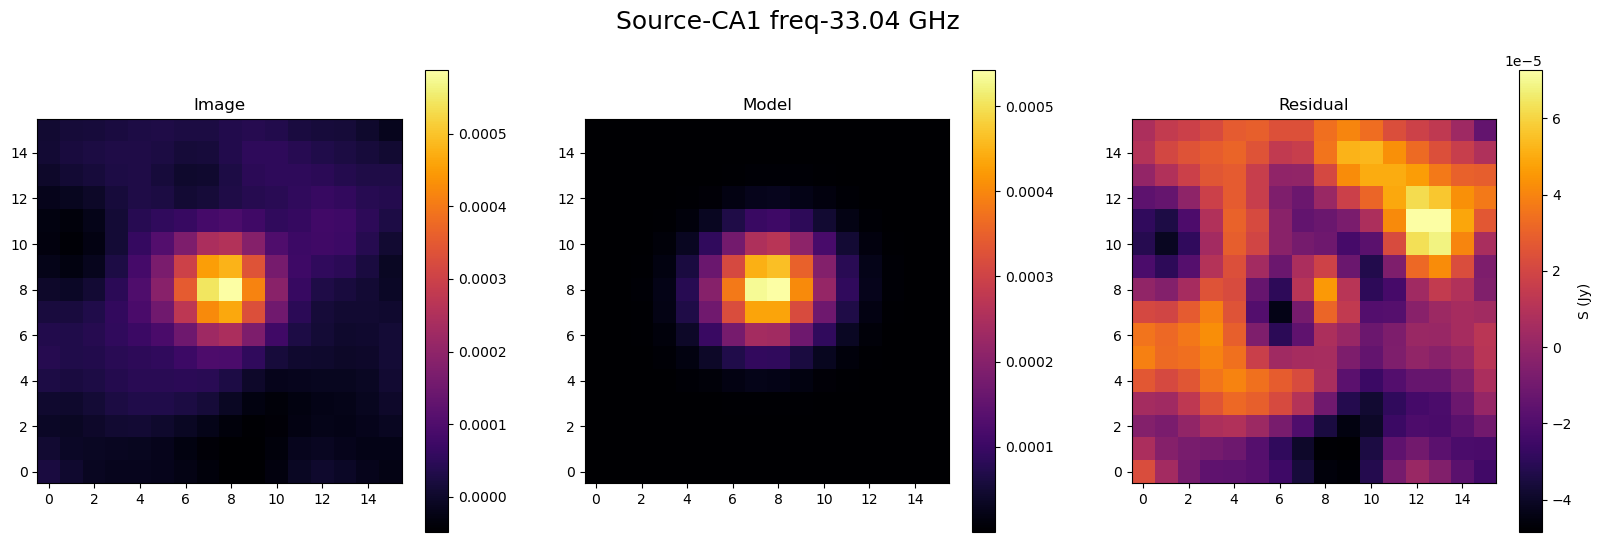

Parameter Error

Amplitude

5.594808435e-04 6.157723311e-05

x_mean

4.929562141e+03 1.971685316e-01

y_mean

5.02306136e+03 1.777839804e-01

x_stddev

1.602415786e+00 1.763683994e-01

y_stddev

1.802876738e+00 1.984357952e-01

theta

1.819476710e+00 6.586319578e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836139, 14.49733258)>


In [8]:
# Ka Band Sources

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/originals_WCS_CRVAL/ICRS/W51_North_KabandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal2.image.tt0.pbcor_ICRS_CRVAL_change.fits'

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=0.03, x=5219, y=4960, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=8, freq='33.04 GHz', source_name='d2')

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=0.03, x=4949, y=5015, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=8, freq='33.04 GHz', source_name='CA3')

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=0.03, x=4949, y=5022, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=4, freq='33.04 GHz', source_name='CA2')

ca3_positions_ICRS = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_ICRS,
                                          amplitude=0.03, x=4930, y=5023, x_stddev=3, y_stddev=3, theta=1.5, 
                                          size=8, freq='33.04 GHz', source_name='CA1')

In [9]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,x_mean_sky,x_mean_sky_error,y_mean_sky,y_mean_sky_error,SkyCoord,frame,header
0,d2,46.99 GHz,8158,7381,2.003131054e-02,5.798740937e-04,8.157218783e+03,1.666791883e-01,7.379360873e+03,1.797205898e-01,290.915907,290.927610,14.518005,14.507756,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
1,CA3,46.99 GHz,7345,7544,1.118561057e-03,6.902485057e-05,7.345059411e+03,2.223309533e-01,7.543367160e+03,2.494930593e-01,290.917072,290.927609,14.518232,14.507756,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
2,CA2,46.99 GHz,7345,7565,1.037389063e-03,1.603143102e-04,7.345172656e+03,6.796907057e-01,7.564952762e+03,4.000221871e-01,290.917072,290.927609,14.518262,14.507756,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
3,CA1,46.99 GHz,7289,7569,9.069292056e-04,5.200514466e-05,7.289449384e+03,2.617564795e-01,7.569039755e+03,2.280370004e-01,290.917152,290.927609,14.518268,14.507756,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
4,d2,33.04 GHz,5219,4960,1.439632876e-02,5.618912281e-04,5.218962184e+03,7.746872079e-02,4.959437972e+03,9.112219274e-02,290.915908,290.938368,14.518003,14.497338,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
5,CA3,33.04 GHz,4949,5015,8.305511630e-04,1.972342333e-04,4.948582191e+03,3.321593183e-01,5.014913826e+03,5.694345869e-01,290.917071,290.938367,14.518234,14.497340,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
6,CA2,33.04 GHz,4949,5022,5.897058205e-04,2.104617761e-04,4.948779772e+03,5.484791165e-01,5.021621338e+03,4.667829145e-01,290.917070,290.938366,14.518262,14.497340,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
7,CA1,33.04 GHz,4930,5023,5.594808435e-04,6.157723311e-05,4.929562141e+03,1.971685316e-01,5.02306136e+03,1.777839804e-01,290.917153,290.938368,14.518268,14.497339,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...


In [10]:
ca3_positions_ICRS

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,x_mean_sky,x_mean_sky_error,y_mean_sky,y_mean_sky_error,SkyCoord,frame,header
0,d2,46.99 GHz,8158,7381,2.003130207e-02,5.798905635e-04,8.157218806e+03,1.666761846e-01,7.379360915e+03,1.797138331e-01,290.915901,290.927603,14.517999,14.507749,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
1,CA3,46.99 GHz,7345,7544,1.118561057e-03,6.902485057e-05,7.345059411e+03,2.223309533e-01,7.543367160e+03,2.494930593e-01,290.917066,290.927603,14.518226,14.507750,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
2,CA2,46.99 GHz,7345,7565,1.037389063e-03,1.603143102e-04,7.345172656e+03,6.796907057e-01,7.564952762e+03,4.000221871e-01,290.917066,290.927603,14.518256,14.507750,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
3,CA1,46.99 GHz,7289,7569,9.069292056e-04,5.200514466e-05,7.289449384e+03,2.617564795e-01,7.569039755e+03,2.280370004e-01,290.917146,290.927603,14.518262,14.507750,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
4,d2,33.04 GHz,5219,4960,1.439632876e-02,5.618912281e-04,5.218962184e+03,7.746872079e-02,4.959437972e+03,9.112219274e-02,290.915901,290.938362,14.517997,14.497332,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
5,CA3,33.04 GHz,4949,5015,8.305511630e-04,1.972342333e-04,4.948582191e+03,3.321593183e-01,5.014913826e+03,5.694345869e-01,290.917065,290.938361,14.518228,14.497334,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
6,CA2,33.04 GHz,4949,5022,5.897058205e-04,2.104617761e-04,4.948779772e+03,5.484791165e-01,5.021621338e+03,4.667829145e-01,290.917064,290.938360,14.518256,14.497334,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
7,CA1,33.04 GHz,4930,5023,5.594808435e-04,6.157723311e-05,4.929562141e+03,1.971685316e-01,5.02306136e+03,1.777839804e-01,290.917147,290.938361,14.518262,14.497333,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...


# d2 Difference in position (ICRS - FK5)

In [17]:
# Difference in positions
print('Freq', '     So.', 'Delta RA (ICRS - FK5)', ' Delta DEC (ICRS - FK5)')

print(ca3_positions['freq'][0], ca3_positions['source'][0] ,float(ca3_positions_ICRS['x_mean_sky'][0] - ca3_positions['x_mean_sky'][0]), float(ca3_positions_ICRS['y_mean_sky'][0] - ca3_positions['y_mean_sky'][0]))
print(ca3_positions['freq'][1], ca3_positions['source'][1] ,float(ca3_positions_ICRS['x_mean_sky'][1] - ca3_positions['x_mean_sky'][1]), float(ca3_positions_ICRS['y_mean_sky'][1] - ca3_positions['y_mean_sky'][1]))
print(ca3_positions['freq'][2], ca3_positions['source'][2] ,float(ca3_positions_ICRS['x_mean_sky'][2] - ca3_positions['x_mean_sky'][2]), float(ca3_positions_ICRS['y_mean_sky'][2] - ca3_positions['y_mean_sky'][2]))
print(ca3_positions['freq'][3], ca3_positions['source'][3] ,float(ca3_positions_ICRS['x_mean_sky'][3] - ca3_positions['x_mean_sky'][3]), float(ca3_positions_ICRS['y_mean_sky'][3] - ca3_positions['y_mean_sky'][3]))
print(ca3_positions['freq'][4], ca3_positions['source'][4] ,float(ca3_positions_ICRS['x_mean_sky'][4] - ca3_positions['x_mean_sky'][4]), float(ca3_positions_ICRS['y_mean_sky'][4] - ca3_positions['y_mean_sky'][4]))
print(ca3_positions['freq'][5], ca3_positions['source'][5] ,float(ca3_positions_ICRS['x_mean_sky'][5] - ca3_positions['x_mean_sky'][5]), float(ca3_positions_ICRS['y_mean_sky'][5] - ca3_positions['y_mean_sky'][5]))
print(ca3_positions['freq'][6], ca3_positions['source'][6] ,float(ca3_positions_ICRS['x_mean_sky'][6] - ca3_positions['x_mean_sky'][6]), float(ca3_positions_ICRS['y_mean_sky'][6] - ca3_positions['y_mean_sky'][6]))
print(ca3_positions['freq'][7], ca3_positions['source'][7] ,float(ca3_positions_ICRS['x_mean_sky'][7] - ca3_positions['x_mean_sky'][7]), float(ca3_positions_ICRS['y_mean_sky'][7] - ca3_positions['y_mean_sky'][7]))


Freq      So. Delta RA (ICRS - FK5)  Delta DEC (ICRS - FK5)
46.99 GHz d2 -6.260718862449721e-06 -6.065885074235666e-06
46.99 GHz CA3 -6.260717782424763e-06 -6.065943408017915e-06
46.99 GHz CA2 -6.260717782424763e-06 -6.065943408017915e-06
46.99 GHz CA1 -6.260719999318098e-06 -6.065943409794272e-06
33.04 GHz d2 -6.260685836423363e-06 -6.065943409794272e-06
33.04 GHz CA3 -6.260717782424763e-06 -6.0659434062415585e-06
33.04 GHz CA2 -6.260717725581344e-06 -6.065943408017915e-06
33.04 GHz CA1 -6.260720056161517e-06 -6.065943404465202e-06


# Separation

In [12]:
d2_47ghz_FK5 = ca3_positions['SkyCoord'][0]
d2_47ghz_ICRS = ca3_positions_ICRS['SkyCoord'][0]


In [13]:
d2_47ghz_FK5, d2_47ghz_ICRS

(<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
     (290.91590709, 14.51800466)>,
 <SkyCoord (ICRS): (ra, dec) in deg
     (290.91590083, 14.5179986)>)

In [20]:
d2_47ghz_FK5 = ca3_positions['SkyCoord'][0]
d2_47ghz_ICRS = ca3_positions_ICRS['SkyCoord'][0]

ca3_47ghz_FK5 = ca3_positions['SkyCoord'][1]
ca3_47ghz_ICRS = ca3_positions_ICRS['SkyCoord'][1]

ca2_47ghz_FK5 = ca3_positions['SkyCoord'][2]
ca2_47ghz_ICRS = ca3_positions_ICRS['SkyCoord'][2]

ca1_47ghz_FK5 = ca3_positions['SkyCoord'][3]
ca1_47ghz_ICRS = ca3_positions_ICRS['SkyCoord'][3]

d2_33ghz_FK5 = ca3_positions['SkyCoord'][4]
d2_33ghz_ICRS = ca3_positions_ICRS['SkyCoord'][4]

ca3_33ghz_FK5 = ca3_positions['SkyCoord'][5]
ca3_33ghz_ICRS = ca3_positions_ICRS['SkyCoord'][5]

ca2_33ghz_FK5 = ca3_positions['SkyCoord'][6]
ca2_33ghz_ICRS = ca3_positions_ICRS['SkyCoord'][6]

ca1_33ghz_FK5 = ca3_positions['SkyCoord'][7]
ca1_33ghz_ICRS = ca3_positions_ICRS['SkyCoord'][7]

In [ ]:

print('Separation between sources in FK5 and ICRS coordinates\n')

print('Freq', ' So.', '   Separation (arcsec)')

print(ca3_positions['freq'][0], ca3_positions['source'][0] ,d2_47ghz_FK5.separation(d2_47ghz_ICRS).arcsec)

print(ca3_positions['freq'][1], ca3_positions['source'][1] ,ca3_47ghz_FK5.separation(ca3_47ghz_ICRS).arcsec)

print(ca3_positions['freq'][2], ca3_positions['source'][2] ,ca2_47ghz_FK5.separation(ca2_47ghz_ICRS).arcsec)

print(ca3_positions['freq'][3], ca3_positions['source'][3] ,ca1_47ghz_FK5.separation(ca1_47ghz_ICRS).arcsec)

print(ca3_positions['freq'][4], ca3_positions['source'][4] ,d2_33ghz_FK5.separation(d2_33ghz_ICRS).arcsec)

print(ca3_positions['freq'][5], ca3_positions['source'][5] ,ca3_33ghz_FK5.separation(ca3_33ghz_ICRS).arcsec)

print(ca3_positions['freq'][6], ca3_positions['source'][6] ,ca2_33ghz_FK5.separation(ca2_33ghz_ICRS).arcsec)

print(ca3_positions['freq'][7], ca3_positions['source'][7] ,ca1_33ghz_FK5.separation(ca1_33ghz_ICRS).arcsec)


Separation between sources in FK5 and ICRS coordinates

Freq  So.    Separation
46.99 GHz d2 2.1750908778009624e-07
46.99 GHz CA3 5.646158848046985e-09
46.99 GHz CA2 5.968279432958064e-09
46.99 GHz CA1 7.83360878726098e-09
33.04 GHz d2 2.3342861595521546e-08
33.04 GHz CA3 5.677076332330363e-09
33.04 GHz CA2 5.844055110331327e-09
33.04 GHz CA1 7.865926074859642e-09
